In [1]:
# %%
#clustering
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from sklearn.decomposition import PCA
import openai
from secret_keys import OPENAI_API_KEY
import logging

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("clustering.log"),
        logging.StreamHandler()
    ]
)

logging.info("Script started")

# Load your OpenAI API key
openai.api_key = OPENAI_API_KEY
logging.info("OpenAI API key loaded")

try:
    # Example usage of the OpenAI API
    response = openai.Completion.create(
        engine="text-davinci-003",
        prompt="Translate the following English text to French: 'Hello, how are you?'",
        max_tokens=60
    )
    logging.info("OpenAI API call successful")
    logging.info(f"OpenAI API response: {response.choices[0].text.strip()}")
except Exception as e:
    logging.error(f"Error during OpenAI API call: {e}")

# Reload the embeddings for clustering and visualization
df = pd.read_csv('../pubmed_results_with_embeddings.csv')
def safe_convert(val):
    try:
        if isinstance(val, str):
            embedding = np.array(eval(val))
        else:
            embedding = np.array(val)
        return embedding if embedding.size > 0 else None
    except:
        return None

# Convert embeddings and filter invalid ones
df['Embedding'] = df['Embedding'].apply(safe_convert)
df = df.dropna(subset=['Embedding'])

# Ensure all embeddings have same length by padding/truncating
#max_len = max(x.shape[0] for x in df['Embedding'])
#embeddings_array = np.array([np.pad(x, (0, max_len - x.shape[0])) for x in df['Embedding']])
#load the embedding sarray, all of the smae dimension already
embeddings_array = np.array(df['Embedding'].values.tolist())
# Scale the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_array)

# Apply PCA to reduce to 50 components (optional)
#pca = PCA(n_components=50, random_state=42)
#pca_result = pca.fit_transform(embeddings_scaled)

# Reduce dimensionality using t-SNE
try:
    logging.info("Starting t-SNE dimensionality reduction")
    tsne = TSNE(
        n_components=2,          # 2D embedding
        perplexity=min(50, len(df)-1),           # Start with default
        learning_rate=400,       # Start with default of 200
        n_iter=1000,             # Number of iterations
        metric='cosine',      # Distance metric
        init='pca',              # PCA initialization
        random_state=42,          # For reproducibility
        early_exaggeration=4,
    )
    embeddings_2d = tsne.fit_transform(embeddings_scaled)
    logging.info("t-SNE dimensionality reduction complete")

    # Apply K-Means clustering
    logging.info("Starting K-Means clustering")
    n_clusters = min(5, len(df))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['Cluster'] = kmeans.fit_predict(embeddings_2d)
    logging.info("K-Means clustering complete")

    # Add t-SNE results to DataFrame
    df['TSNE_1'] = embeddings_2d[:, 0]
    df['TSNE_2'] = embeddings_2d[:, 1]
    logging.info("t-SNE results added to DataFrame")

    # Plot using plotly
    logging.info("Creating plotly scatter plot")
    fig = px.scatter(df, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
    fig.show()
    fig.write_html('outputs/t-SNE_visualization.html')
    fig.write_image('outputs/t-SNE_visualization_plotly.pdf')
    logging.info("Plotly scatter plot created and saved")

    # Calculate cluster metrics
    logging.info("Calculating cluster metrics")
    df['Cluster_Size'] = df.groupby('Cluster')['Cluster'].transform('count')
    df['Cluster_Density'] = df.groupby('Cluster')['Cluster'].transform(lambda x: len(x)/len(df))
    logging.info("Cluster metrics calculated")

    # Save results
    df.to_csv('outputs/labeled_clusters.csv', index=False)
    logging.info("Clustering complete - results saved to labeled_clusters.csv")
except Exception as e:
    logging.error(f"Error during clustering process: {e}")

logging.info("Script finished")


KeyboardInterrupt: 

In [ ]:
# %%
# Query the DataFrame for rows containing all words in the title
search_words = "impacts of heat exposure on pregnant women, fetuses and newborns" #replace with your search terms
filtered_df = df[df['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
print(filtered_df[['Cluster']])

                                                   Title  Cluster
59954  Impacts of heat exposure on pregnant women, fe...        0
       Cluster
59954        0


In [17]:
# Subset the DataFrame for Cluster of interest
df_subset = df[(df['Cluster'] == 0)]

In [28]:
# Convert embeddings and filter invalid ones
df_subset['Embedding'] = df_subset['Embedding'].apply(safe_convert)
df_subset = df_subset.dropna(subset=['Embedding'])

# Ensure all embeddings have same length by padding/truncating
#max_len = max(x.shape[0] for x in df['Embedding'])
#embeddings_array = np.array([np.pad(x, (0, max_len - x.shape[0])) for x in df['Embedding']])
#load the embedding sarray, all of the smae dimension already
embeddings_array = np.array(df_subset['Embedding'].values.tolist())
# Scale the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_array)

# Apply PCA to reduce to 50 components (optional)
#pca = PCA(n_components=50, random_state=42)
#pca_result = pca.fit_transform(embeddings_scaled)

# Reduce dimensionality using t-SNE
try:
    #logging.info("Starting t-SNE dimensionality reduction")
    tsne = TSNE(
        n_components=2,          # 2D embedding
        perplexity=min(50, len(df_subset)-1),           # Start with default
        learning_rate=400,       # Start with default of 200
        n_iter=1000,             # Number of iterations
        metric='cosine',      # Distance metric
        init='pca',              # PCA initialization
        random_state=42,          # For reproducibility
        early_exaggeration=4,
    )
    embeddings_2d = tsne.fit_transform(embeddings_scaled)
    #logging.info("t-SNE dimensionality reduction complete")
    # Add t-SNE results to DataFrame
    df_subset['TSNE_1'] = embeddings_2d[:, 0]
    df_subset['TSNE_2'] = embeddings_2d[:, 1]
    #logging.info("t-SNE results added to DataFrame")
except Exception as e:
    l#ogging.error(f"Error during clustering process: {e}")

#logging.info("Script finished")

/var/folders/zr/krd9bths2x19_mx5sdr4lc_r0000gn/T/ipykernel_98532/3188018820.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/nicbrink/anaconda3/envs/ml_review/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



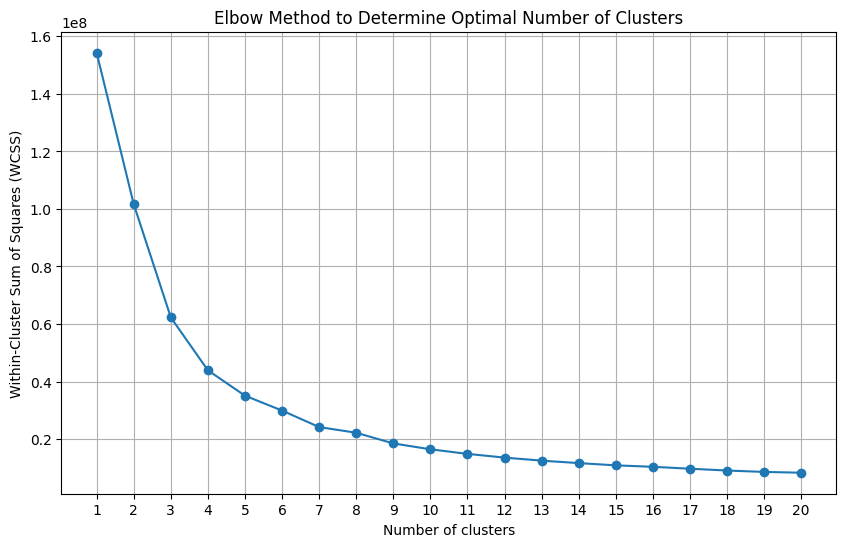

In [29]:
# %%
# Determine Optimal Number of Clusters using Elbow Method
wcss = []
cluster_range = range(1, 21)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(cluster_range, wcss, marker='o')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [30]:
#Set optimal number of clusters
n_clusters = 8

In [34]:
# Apply K-Means clustering
try:
    #logging.info("Starting K-Means clustering")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_subset['Cluster'] = kmeans.fit_predict(embeddings_2d)
    #logging.info("K-Means clustering complete")
    # Plot using plotly
    #logging.info("Creating plotly scatter plot")
    fig = px.scatter(df_subset, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
    #fig.show()
    fig.write_html('outputs/t-SNE_visualization_subset.html')
    #fig.write_image('outputs/t-SNE_visualization_plotly_subset.pdf')
    #logging.info("Plotly scatter plot created and saved")

    # Calculate cluster metrics
    #logging.info("Calculating cluster metrics")
    df_subset['Cluster_Size'] = df_subset.groupby('Cluster')['Cluster'].transform('count')
    df_subset['Cluster_Density'] = df_subset.groupby('Cluster')['Cluster'].transform(lambda x: len(x)/len(df_subset))
    #logging.info("Cluster metrics calculated")

    # Save results
    df_subset.to_csv('outputs/labeled_clusters_subset.csv', index=False)
    #logging.info("Clustering complete - results saved to labeled_clusters.csv")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

In [35]:
# %% Maternal Health
# Query the DataFrame for rows containing all words in the title
search_words = "impacts of heat exposure on pregnant women, fetuses and newborns"
filtered_df = df_subset[df_subset['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
print(filtered_df[['Cluster']])

                                                   Title  Cluster
59954  Impacts of heat exposure on pregnant women, fe...        1
       Cluster
59954        1


In [36]:
# %% Mental Health 
# Query the DataFrame for rows containing all words in the title
search_words = "Ambient temperature and mental health: a systematic review and meta-analysis"
filtered_df = df_subset[df_subset['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
print(filtered_df[['Cluster']])

                                                   Title  Cluster
29260  Ambient temperature and mental health: a syste...        1
       Cluster
29260        1


In [42]:
df_subset.shape

(72561, 13)

In [43]:
# Subset the DataFrame for Cluster of interest and one more
df_subset_2 = df_subset[(df_subset['Cluster'] == 1) | (df_subset['Cluster'] == 3)]

In [44]:
df_subset_2.shape

(19805, 13)

In [45]:
# Convert embeddings and filter invalid ones
df_subset_2['Embedding'] = df_subset_2['Embedding'].apply(safe_convert)
df_subset_2 = df_subset_2.dropna(subset=['Embedding'])

# Ensure all embeddings have same length by padding/truncating
#max_len = max(x.shape[0] for x in df['Embedding'])
#embeddings_array = np.array([np.pad(x, (0, max_len - x.shape[0])) for x in df['Embedding']])
#load the embedding sarray, all of the smae dimension already
embeddings_array = np.array(df_subset_2['Embedding'].values.tolist())
# Scale the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_array)

# Apply PCA to reduce to 50 components (optional)
#pca = PCA(n_components=50, random_state=42)
#pca_result = pca.fit_transform(embeddings_scaled)

# Reduce dimensionality using t-SNE
try:
    #logging.info("Starting t-SNE dimensionality reduction")
    tsne = TSNE(
        n_components=2,          # 2D embedding
        perplexity=min(50, len(df_subset_2)-1),           # Start with default
        learning_rate=400,       # Start with default of 200
        n_iter=1000,             # Number of iterations
        metric='cosine',      # Distance metric
        init='pca',              # PCA initialization
        random_state=42,          # For reproducibility
        early_exaggeration=4,
    )
    embeddings_2d = tsne.fit_transform(embeddings_scaled)
    #logging.info("t-SNE dimensionality reduction complete")
    # Add t-SNE results to DataFrame
    df_subset_2['TSNE_1'] = embeddings_2d[:, 0]
    df_subset_2['TSNE_2'] = embeddings_2d[:, 1]
    #logging.info("t-SNE results added to DataFrame")
except Exception as e:
    l#ogging.error(f"Error during clustering process: {e}")

#logging.info("Script finished")

/var/folders/zr/krd9bths2x19_mx5sdr4lc_r0000gn/T/ipykernel_98532/2275078887.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/nicbrink/anaconda3/envs/ml_review/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



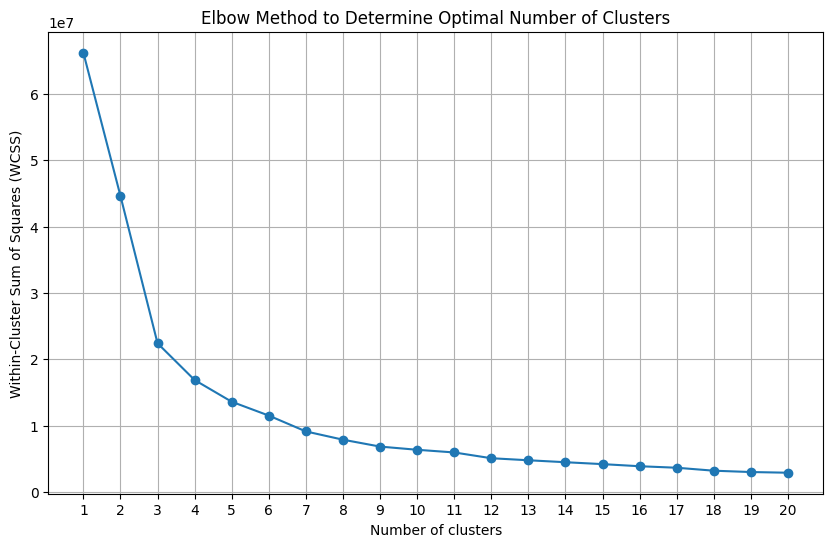

In [46]:
# %%
# Determine Optimal Number of Clusters using Elbow Method
wcss = []
cluster_range = range(1, 21)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(cluster_range, wcss, marker='o')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [47]:
#Set optimal number of clusters
n_clusters = 3

In [48]:
# Apply K-Means clustering
try:
    #logging.info("Starting K-Means clustering")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_subset_2['Cluster'] = kmeans.fit_predict(embeddings_2d)
    #logging.info("K-Means clustering complete")
    # Plot using plotly
    #logging.info("Creating plotly scatter plot")
    fig = px.scatter(df_subset_2, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
    #fig.show()
    fig.write_html('outputs/t-SNE_visualization_subset_2.html')
    #fig.write_image('outputs/t-SNE_visualization_plotly_subset_2.pdf')
    #logging.info("Plotly scatter plot created and saved")

    # Calculate cluster metrics
    #logging.info("Calculating cluster metrics")
    df_subset_2['Cluster_Size'] = df_subset_2.groupby('Cluster')['Cluster'].transform('count')
    df_subset_2['Cluster_Density'] = df_subset_2.groupby('Cluster')['Cluster'].transform(lambda x: len(x)/len(df_subset_2))
    #logging.info("Cluster metrics calculated")

    # Save results
    df_subset_2.to_csv('outputs/labeled_clusters_subset_2.csv', index=False)
    #logging.info("Clustering complete - results saved to labeled_clusters.csv")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

In [50]:
# %% Maternal Health
# Query the DataFrame for rows containing all words in the title
search_words = "impacts of heat exposure on pregnant women, fetuses and newborns"
filtered_df = df_subset_2[df_subset_2['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
print(filtered_df[['Cluster']])

                                                   Title  Cluster
59954  Impacts of heat exposure on pregnant women, fe...        0
       Cluster
59954        0


In [64]:
# %% Mental Health 
# Query the DataFrame for rows containing all words in the title
search_words = "Ambient temperature and mental health: a systematic review and meta-analysis"
filtered_df = df_subset_2[df_subset_2['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
print(filtered_df[['Cluster']])

                                                   Title  Cluster
29260  Ambient temperature and mental health: a syste...        2
       Cluster
29260        2


Need to split at this point to continue maternal review and mental health review

In [65]:
#mental_health
# Subset the DataFrame for Cluster of interest
df_subset_mental_health = df_subset_2[(df_subset_2['Cluster'] == 2)]

In [66]:
df_subset_mental_health.shape

(7431, 13)

In [76]:
# Convert embeddings and filter invalid ones
df_subset_mental_health['Embedding'] = df_subset_mental_health['Embedding'].apply(safe_convert)
df_subset_mental_health = df_subset_mental_health.dropna(subset=['Embedding'])

# Ensure all embeddings have same length by padding/truncating
#max_len = max(x.shape[0] for x in df['Embedding'])
#embeddings_array = np.array([np.pad(x, (0, max_len - x.shape[0])) for x in df['Embedding']])
#load the embedding sarray, all of the smae dimension already
embeddings_array = np.array(df_subset_mental_health['Embedding'].values.tolist())
# Scale the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_array)

# Apply PCA to reduce to 50 components (optional)
#pca = PCA(n_components=50, random_state=42)
#pca_result = pca.fit_transform(embeddings_scaled)

# Reduce dimensionality using t-SNE
try:
    #logging.info("Starting t-SNE dimensionality reduction")
    tsne = TSNE(
        n_components=2,          # 2D embedding
        perplexity=min(20, len(df_subset_mental_health)-1),           # Start with default
        learning_rate=400,       # Start with default of 200
        n_iter=1000,             # Number of iterations
        metric='cosine',      # Distance metric
        init='pca',              # PCA initialization
        random_state=42,          # For reproducibility
        early_exaggeration=4,
    )
    embeddings_2d = tsne.fit_transform(embeddings_scaled)
    #logging.info("t-SNE dimensionality reduction complete")
    # Add t-SNE results to DataFrame
    df_subset_mental_health['TSNE_1'] = embeddings_2d[:, 0]
    df_subset_mental_health['TSNE_2'] = embeddings_2d[:, 1]
    #logging.info("t-SNE results added to DataFrame")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

#logging.info("Script finished")

/Users/nicbrink/anaconda3/envs/ml_review/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



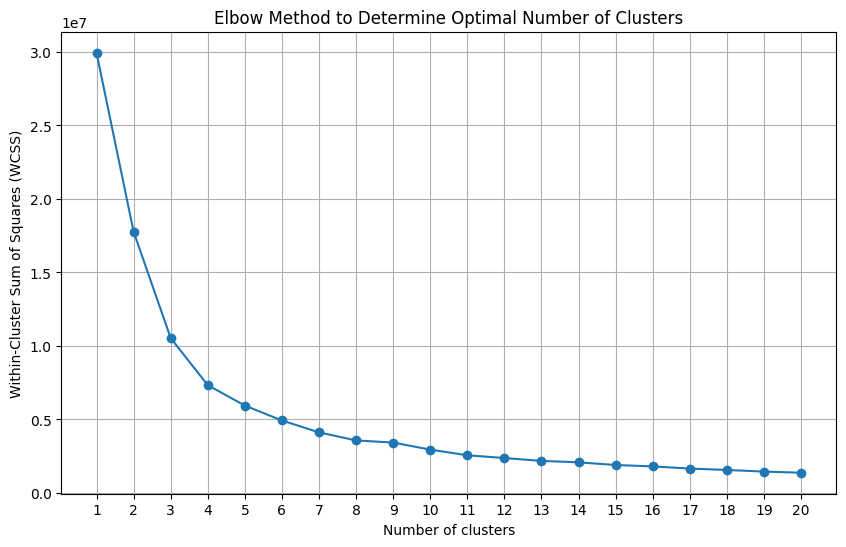

In [77]:
# %%
# Determine Optimal Number of Clusters using Elbow Method
wcss = []
cluster_range = range(1, 21)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(cluster_range, wcss, marker='o')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [78]:
#Set optimal number of clusters
n_clusters = 4

In [79]:
# Apply K-Means clustering
try:
    #logging.info("Starting K-Means clustering")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_subset_mental_health['Cluster'] = kmeans.fit_predict(embeddings_2d)
    #logging.info("K-Means clustering complete")
    # Plot using plotly
    #logging.info("Creating plotly scatter plot")
    fig = px.scatter(df_subset_mental_health, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
    #fig.show()
    fig.write_html('outputs/t-SNE_visualization_subset_mental_health.html')
    #fig.write_image('outputs/t-SNE_visualization_plotly_subset_mental_health.pdf')
    #logging.info("Plotly scatter plot created and saved")

    # Calculate cluster metrics
    #logging.info("Calculating cluster metrics")
    df_subset_mental_health['Cluster_Size'] = df_subset_mental_health.groupby('Cluster')['Cluster'].transform('count')
    df_subset_mental_health['Cluster_Density'] = df_subset_mental_health.groupby('Cluster')['Cluster'].transform(lambda x: len(x)/len(df_subset_mental_health))
    #logging.info("Cluster metrics calculated")

    # Save results
    df_subset_mental_health.to_csv('outputs/labeled_clusters_subset_mental_health.csv', index=False)
    #logging.info("Clustering complete - results saved to labeled_clusters.csv")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

In [80]:
# %% Mental Health 
# Query the DataFrame for rows containing all words in the title
search_words = "Ambient temperature and mental health: a systematic review and meta-analysis"
filtered_df = df_subset_mental_health[df_subset_mental_health['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
print(filtered_df[['Cluster']])

                                                   Title  Cluster
29260  Ambient temperature and mental health: a syste...        2
       Cluster
29260        2


In [81]:
df_subset_mental_health.shape

(7431, 13)

In [82]:
#mental_health
# Subset the DataFrame for Cluster of interest
df_subset_mental_health_2 = df_subset_mental_health[(df_subset_mental_health['Cluster'] == 2)]

In [83]:
# Convert embeddings and filter invalid ones
df_subset_mental_health_2['Embedding'] = df_subset_mental_health_2['Embedding'].apply(safe_convert)
df_subset_mental_health_2 = df_subset_mental_health_2.dropna(subset=['Embedding'])

# Ensure all embeddings have same length by padding/truncating
#max_len = max(x.shape[0] for x in df['Embedding'])
#embeddings_array = np.array([np.pad(x, (0, max_len - x.shape[0])) for x in df['Embedding']])
#load the embedding sarray, all of the smae dimension already
embeddings_array = np.array(df_subset_mental_health_2['Embedding'].values.tolist())
# Scale the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_array)

# Apply PCA to reduce to 50 components (optional)
#pca = PCA(n_components=50, random_state=42)
#pca_result = pca.fit_transform(embeddings_scaled)

# Reduce dimensionality using t-SNE
try:
    #logging.info("Starting t-SNE dimensionality reduction")
    tsne = TSNE(
        n_components=2,          # 2D embedding
        perplexity=min(20, len(df_subset_mental_health_2)-1),           # Start with default
        learning_rate=400,       # Start with default of 200
        n_iter=1000,             # Number of iterations
        metric='cosine',      # Distance metric
        init='pca',              # PCA initialization
        random_state=42,          # For reproducibility
        early_exaggeration=4,
    )
    embeddings_2d = tsne.fit_transform(embeddings_scaled)
    #logging.info("t-SNE dimensionality reduction complete")
    # Add t-SNE results to DataFrame
    df_subset_mental_health_2['TSNE_1'] = embeddings_2d[:, 0]
    df_subset_mental_health_2['TSNE_2'] = embeddings_2d[:, 1]
    #logging.info("t-SNE results added to DataFrame")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

#logging.info("Script finished")

/var/folders/zr/krd9bths2x19_mx5sdr4lc_r0000gn/T/ipykernel_98532/930077696.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/nicbrink/anaconda3/envs/ml_review/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



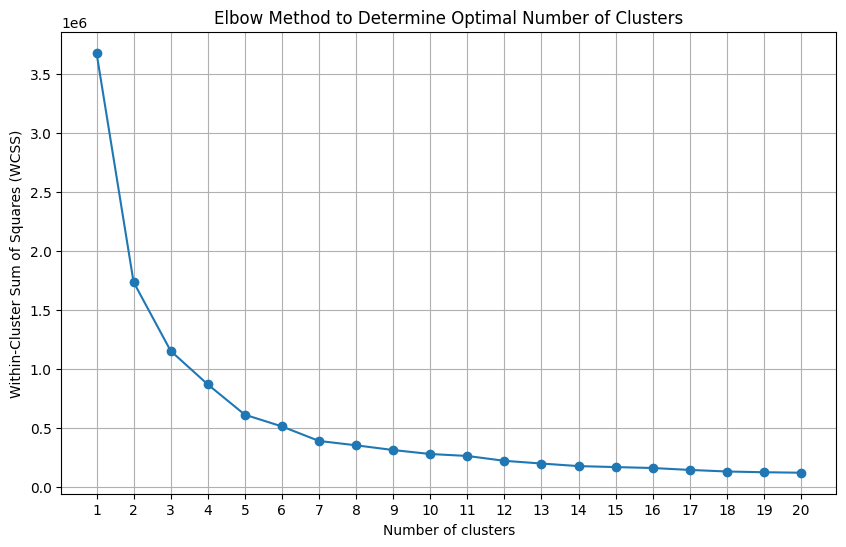

In [84]:
# %%
# Determine Optimal Number of Clusters using Elbow Method
wcss = []
cluster_range = range(1, 21)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(cluster_range, wcss, marker='o')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [85]:
#Set optimal number of clusters
n_clusters = 5

In [86]:
# Apply K-Means clustering
try:
    #logging.info("Starting K-Means clustering")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_subset_mental_health_2['Cluster'] = kmeans.fit_predict(embeddings_2d)
    #logging.info("K-Means clustering complete")
    # Plot using plotly
    #logging.info("Creating plotly scatter plot")
    fig = px.scatter(df_subset_mental_health_2, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
    #fig.show()
    fig.write_html('outputs/t-SNE_visualization_subset_mental_health_2.html')
    #fig.write_image('outputs/t-SNE_visualization_plotly_subset_mental_health.pdf')
    #logging.info("Plotly scatter plot created and saved")

    # Calculate cluster metrics
    #logging.info("Calculating cluster metrics")
    df_subset_mental_health_2['Cluster_Size'] = df_subset_mental_health_2.groupby('Cluster')['Cluster'].transform('count')
    df_subset_mental_health_2['Cluster_Density'] = df_subset_mental_health_2.groupby('Cluster')['Cluster'].transform(lambda x: len(x)/len(df_subset_mental_health))
    #logging.info("Cluster metrics calculated")

    # Save results
    df_subset_mental_health_2.to_csv('outputs/labeled_clusters_subset_mental_health_2.csv', index=False)
    #logging.info("Clustering complete - results saved to labeled_clusters.csv")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

In [92]:
# %% Mental Health 
# Query the DataFrame for rows containing all words in the title
search_words = "mental health"
filtered_df = df_subset_mental_health_2[df_subset_mental_health_2['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
#count number of studies in each cluster
print(filtered_df['Cluster'].value_counts())

                                                    Title  Cluster
1595    Chronic high temperature exposure, brain struc...        4
2504    A scoping review of the impact of eco-distress...        4
4036                [Planetary health and mental health].        4
5442    A Systematic Review of the Impact of Energy In...        2
15041   The more you know: Insights from integrated pr...        3
29260   Ambient temperature and mental health: a syste...        4
33479   Scoping review of climate change and mental he...        4
39923   Climate distress, climate-sensitive risk facto...        4
41834   High temperatures on mental health: Recognizin...        4
44728   Environmental health, economy, and amenities i...        4
58452   Impact of air pollution and climate change on ...        4
60058   Residential natural hazard risk and mental hea...        4
60499   Examining the non-linear association between a...        4
115725  Climate change and mental health: a causal pat...     

In [93]:
#mental_health
# Subset the DataFrame for Cluster of interest
df_subset_mental_health_3 = df_subset_mental_health_2[(df_subset_mental_health_2['Cluster'] == 4)]

In [94]:
df_subset_mental_health_3.shape

(399, 13)

In [95]:
# Convert embeddings and filter invalid ones
df_subset_mental_health_3['Embedding'] = df_subset_mental_health_3['Embedding'].apply(safe_convert)
df_subset_mental_health_3 = df_subset_mental_health_3.dropna(subset=['Embedding'])

# Ensure all embeddings have same length by padding/truncating
#max_len = max(x.shape[0] for x in df['Embedding'])
#embeddings_array = np.array([np.pad(x, (0, max_len - x.shape[0])) for x in df['Embedding']])
#load the embedding sarray, all of the smae dimension already
embeddings_array = np.array(df_subset_mental_health_3['Embedding'].values.tolist())
# Scale the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_array)

# Apply PCA to reduce to 50 components (optional)
#pca = PCA(n_components=50, random_state=42)
#pca_result = pca.fit_transform(embeddings_scaled)

# Reduce dimensionality using t-SNE
try:
    #logging.info("Starting t-SNE dimensionality reduction")
    tsne = TSNE(
        n_components=2,          # 2D embedding
        perplexity=min(20, len(df_subset_mental_health_3)-1),           # Start with default
        learning_rate=400,       # Start with default of 200
        n_iter=1000,             # Number of iterations
        metric='cosine',      # Distance metric
        init='pca',              # PCA initialization
        random_state=42,          # For reproducibility
        early_exaggeration=4,
    )
    embeddings_2d = tsne.fit_transform(embeddings_scaled)
    #logging.info("t-SNE dimensionality reduction complete")
    # Add t-SNE results to DataFrame
    df_subset_mental_health_3['TSNE_1'] = embeddings_2d[:, 0]
    df_subset_mental_health_3['TSNE_2'] = embeddings_2d[:, 1]
    #logging.info("t-SNE results added to DataFrame")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

#logging.info("Script finished")

/var/folders/zr/krd9bths2x19_mx5sdr4lc_r0000gn/T/ipykernel_98532/208165447.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/nicbrink/anaconda3/envs/ml_review/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



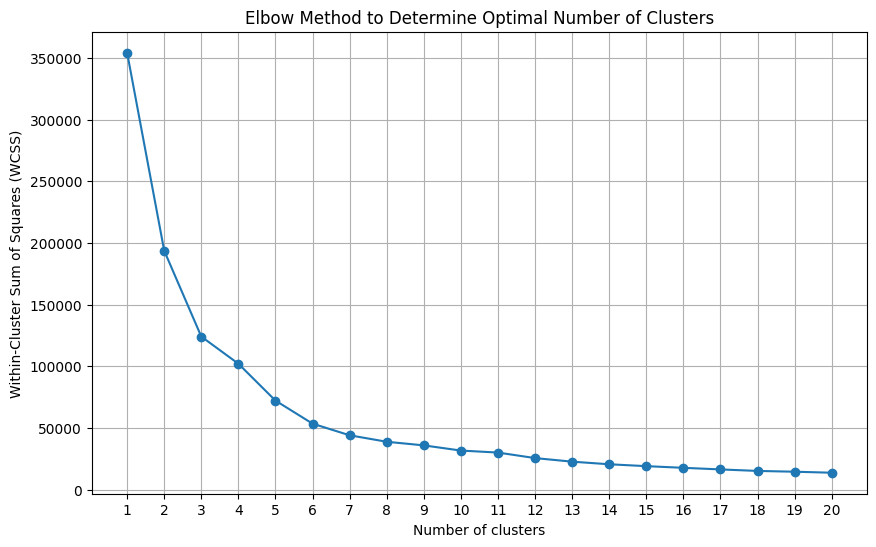

In [96]:
# %%
# Determine Optimal Number of Clusters using Elbow Method
wcss = []
cluster_range = range(1, 21)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(cluster_range, wcss, marker='o')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [97]:
#Set optimal number of clusters
n_clusters = 3

In [98]:
# Apply K-Means clustering
try:
    #logging.info("Starting K-Means clustering")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_subset_mental_health_3['Cluster'] = kmeans.fit_predict(embeddings_2d)
    #logging.info("K-Means clustering complete")
    # Plot using plotly
    #logging.info("Creating plotly scatter plot")
    fig = px.scatter(df_subset_mental_health_3, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
    #fig.show()
    fig.write_html('outputs/t-SNE_visualization_subset_mental_health_3.html')
    #fig.write_image('outputs/t-SNE_visualization_plotly_subset_mental_health.pdf')
    #logging.info("Plotly scatter plot created and saved")

    # Calculate cluster metrics
    #logging.info("Calculating cluster metrics")
    df_subset_mental_health_3['Cluster_Size'] = df_subset_mental_health_3.groupby('Cluster')['Cluster'].transform('count')
    df_subset_mental_health_3['Cluster_Density'] = df_subset_mental_health_3.groupby('Cluster')['Cluster'].transform(lambda x: len(x)/len(df_subset_mental_health_3))
    #logging.info("Cluster metrics calculated")

    # Save results
    df_subset_mental_health_3.to_csv('outputs/labeled_clusters_subset_mental_health_3.csv', index=False)
    #logging.info("Clustering complete - results saved to labeled_clusters.csv")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

In [99]:
#subset to cluster 1 for final_df
#mental_health
# Subset the DataFrame for Cluster of interest
df_subset_mental_health_final = df_subset_mental_health_3[(df_subset_mental_health_3['Cluster'] == 1)]

In [100]:
#save to csv
df_subset_mental_health_final.to_csv('outputs/mental_health_final.csv', index=False)

In [101]:
#count number of studies in each cluster
print(df_subset_mental_health_final['Cluster'].value_counts())

Cluster
1    146
Name: count, dtype: int64
